# To simulate a real time training for an ARMA model 

In [36]:
import pandas as pd 
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import numpy as np
import matplotlib.pyplot as plt

We implement a class to test ARMA models against the other models 

In [37]:
class ARMA_model():
    def __init__(self, time_series: pd.Series, order: tuple, horizon: int, test_size: float):
        self.data = time_series
        self.order = order
        self.horizon = horizon
        self.test_size = test_size
        self.T = len(self.data)
        self.split_location = int(self.T * (1 - test_size))
        self.y_true = self.data[self.split_location:]

    def predict(self):
        y_pred = []
        j = self.split_location
        while j < self.T:
            steps_to_forecast = min(self.horizon, self.T - j)
            data_to_train = self.data[:j]
            model = SARIMAX(endog=data_to_train, order=(self.order[0], 0, self.order[1])).fit(disp=False)
            predictions = model.forecast(steps=steps_to_forecast)
            y_pred.extend(predictions)
            j += steps_to_forecast
        self.y_pred = np.array(y_pred[:len(self.y_true)])
        return self.y_pred

    def measure_performance(self, minutes_list):
        metrics = [mean_squared_error, mean_absolute_error, mean_absolute_percentage_error]
        metric_names = ['MSE', 'MAE', 'MAPE']
        array_results = np.zeros(shape=(len(metric_names), len(minutes_list)))

        results = {m: ([], []) for m in minutes_list}  # (y_true, y_pred)

        j = self.split_location
        while j < self.T:
            horizon_available = min(self.horizon, self.T - j)
            for m in minutes_list:
                if m <= horizon_available:
                    idx = j - self.split_location + m - 1
                    if idx < len(self.y_true):
                        y_true_m = self.y_true.iloc[idx]
                        y_pred_m = self.y_pred[idx]
                        results[m][0].append(y_true_m)
                        results[m][1].append(y_pred_m)
            j += horizon_available

        for i, metric in enumerate(metrics):
            for j, m in enumerate(minutes_list):
                y_t, y_p = results[m]
                if len(y_t) > 0:
                    array_results[i, j] = metric(y_t, y_p)
                else:
                    array_results[i, j] = np.nan

        return pd.DataFrame(data=array_results, index=metric_names, columns=minutes_list)


In [38]:
glucose = pd.read_csv('../Data/Preprocessed/HUPA0022P.csv', sep=';')['glucose']
arma_model = ARMA_model(time_series=glucose, order=(1,2), horizon=12, test_size=0.3)

In [39]:
y_pred = arma_model.predict()
y_true = arma_model.y_true

In [40]:
arma_model.measure_performance(minutes_list=list(range(1,13)))

,1,2,3,4,5,6,7,8,9,10,11,12
MSE,51.506716,74.828747,125.764214,190.111976,172.811698,171.826595,203.094048,263.729270,339.402617,407.000910,420.421550,395.628331
MAE,3.294059,5.005567,6.775465,8.254390,9.031781,9.652951,10.542101,11.533147,12.973911,13.696284,14.475357,14.473437
MAPE,0.033107,0.050849,0.067577,0.082799,0.092515,0.100310,0.109703,0.115951,0.128846,0.137243,0.145389,0.148481


In [41]:
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)

MAPE:0.10092286964988907
MAE:9.961392890497658
MSE:234.13638034954633


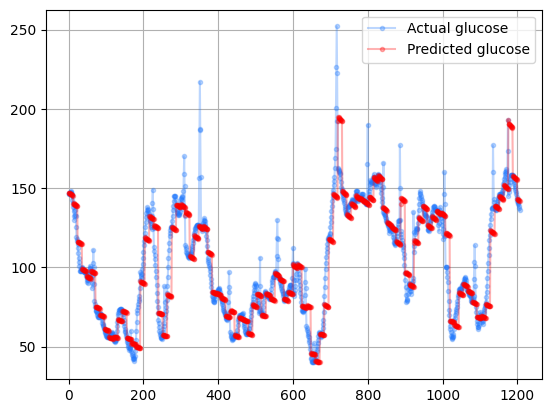

In [43]:
print(f'MAPE:{mape}')
print(f'MAE:{mae}')
print(f'MSE:{mse}')
plt.plot(range(len(y_pred)), y_true, label='Actual glucose', marker='.', color='#237AFC', alpha=0.3)
plt.plot(range(len(y_pred)), y_pred, label='Predicted glucose', marker='.', color='red', alpha=0.3)
plt.legend()
plt.grid()
plt.show()